In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('data/dataprocessing_v3.csv')
df = df.drop(columns=['Version'])
df.head()

,Brand,Series,Max Tension,Tech_Frame,Tech_Material,Tech_Stability,Origin,Price
0,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1140000.0
1,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1140007.0
2,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1139947.0
3,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1139966.0
4,Lining,3D,30.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM","WING STABILIZER, 3D CALIBAR, STABILIZED TORSIO...",China,1150000.0


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6256 entries, 0 to 6255
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           6256 non-null   object 
 1   Series          6256 non-null   object 
 2   Max Tension     6256 non-null   float64
 3   Tech_Frame      5012 non-null   object 
 4   Tech_Material   5200 non-null   object 
 5   Tech_Stability  4576 non-null   object 
 6   Origin          6256 non-null   object 
 7   Price           6236 non-null   float64
dtypes: float64(2), object(6)
memory usage: 391.1+ KB
--------------------------------------------------
Thống kê các cột dạng num:


,Max Tension,Price
count,6256.000000,6.236000e+03
mean,28.347187,2.034588e+06
std,3.090169,1.337905e+06
min,18.000000,3.599190e+05
25%,26.000000,1.097094e+06
50%,28.000000,1.590000e+06
75%,30.000000,2.738908e+06
max,38.000000,1.350009e+07


--------------------------------------------------
Thống kê các cột phân loại (text)


,Brand,Series,Tech_Frame,Tech_Material,Tech_Stability,Origin
count,6256,6256,5012,5200,4576,6256
unique,8,346,161,160,206,4
top,Yonex,Astrox,OPTIMUM FRAME,HIGH MODULUS GRAPHITE,SEVEN-SIX 76,Japan
freq,1952,520,748,328,236,3092


Số lượng giá trị bị thiếu:
 Brand                0
Series               0
Max Tension          0
Tech_Frame        1244
Tech_Material     1056
Tech_Stability    1680
Origin               0
Price               20
dtype: int64


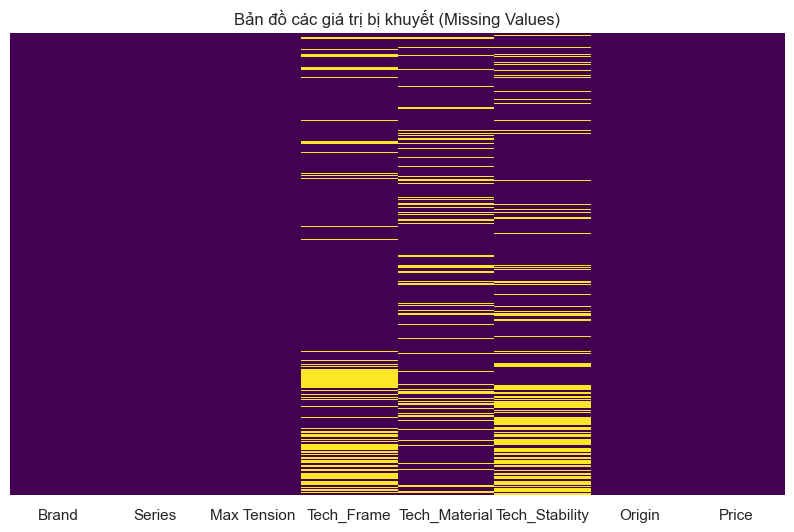

In [3]:
sns.set_theme(style="whitegrid")

print('Thông tin dữ liệu:')
df.info()
print("-" * 50)
print('Thống kê các cột dạng num:')
display(df.describe())
print("-" * 50)
print('Thống kê các cột phân loại (text)')
display(df.describe(include=['object']))

print("Số lượng giá trị bị thiếu:\n",df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Bản đồ các giá trị bị khuyết (Missing Values)')
plt.show()

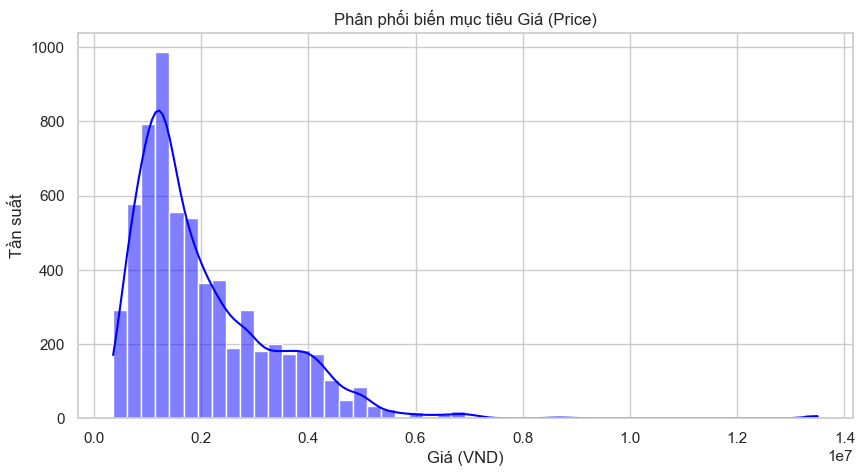

C:\Users\khacb\AppData\Local\Temp\ipykernel_23920\2372078381.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Brand', order=df['Brand'].value_counts().index, palette='Set2')


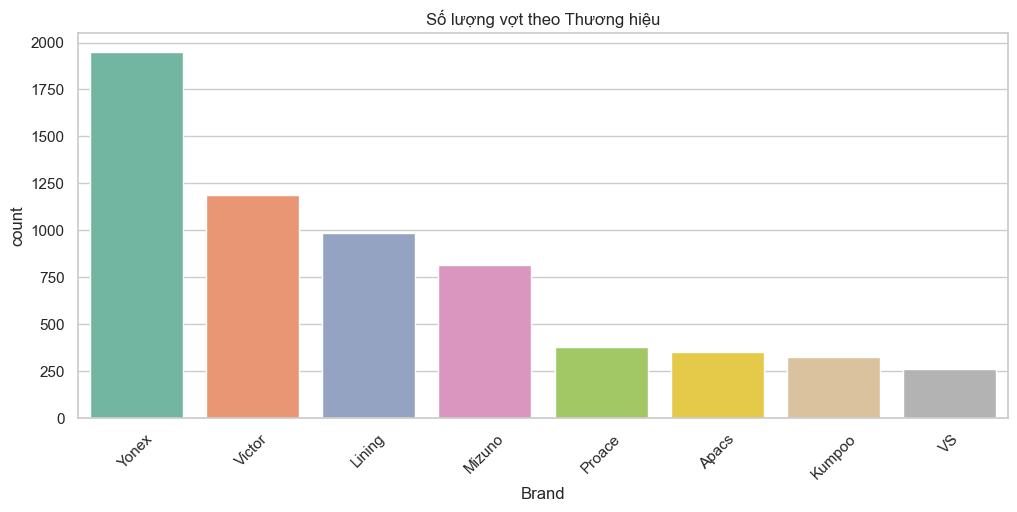

C:\Users\khacb\AppData\Local\Temp\ipykernel_23920\2372078381.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Origin', order=df['Origin'].value_counts().index, palette='Set1')


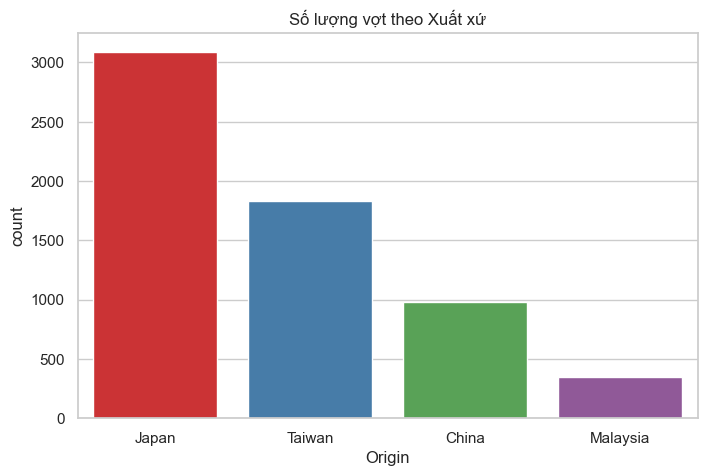

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=50, kde=True, color='blue')
plt.title('Phân phối biến mục tiêu Giá (Price)')
plt.xlabel('Giá (VND)')
plt.ylabel('Tần suất')
plt.show()

# Số lượng vợt theo từng thương hiệu
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Brand', order=df['Brand'].value_counts().index, palette='Set2')
plt.title('Số lượng vợt theo Thương hiệu')
plt.xticks(rotation=45)
plt.show()
# Số lượng vợt theo nơi sản xuất (Origin)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Origin', order=df['Origin'].value_counts().index, palette='Set1')
plt.title('Số lượng vợt theo Xuất xứ')
plt.show()

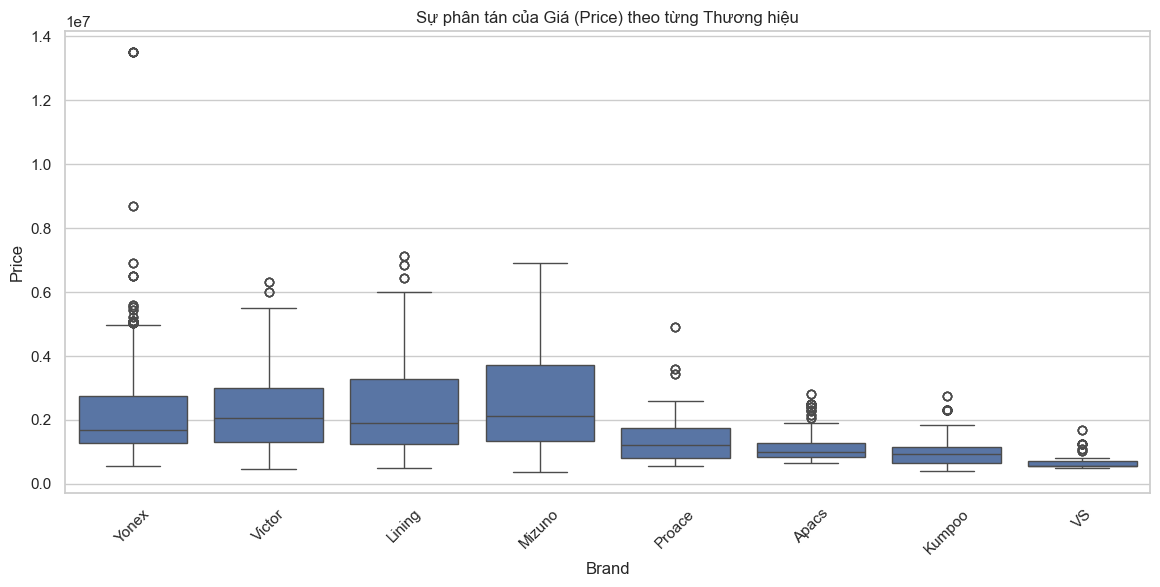

In [5]:
# phân tích hai biến
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Brand', y='Price', order=df['Brand'].value_counts().index)
plt.title('Sự phân tán của Giá (Price) theo từng Thương hiệu')
plt.xticks(rotation=45)
plt.show()

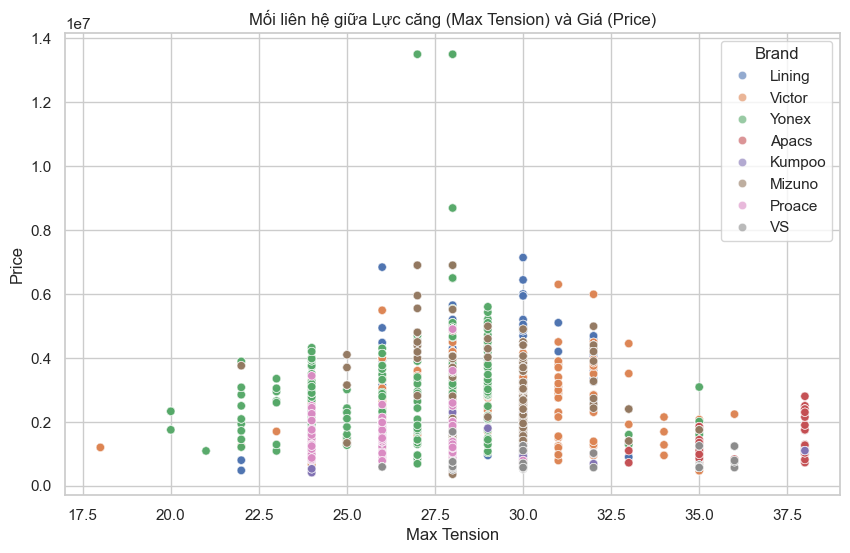

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Max Tension', y='Price', hue='Brand', alpha=0.6)
plt.title('Mối liên hệ giữa Lực căng (Max Tension) và Giá (Price)')
plt.show()


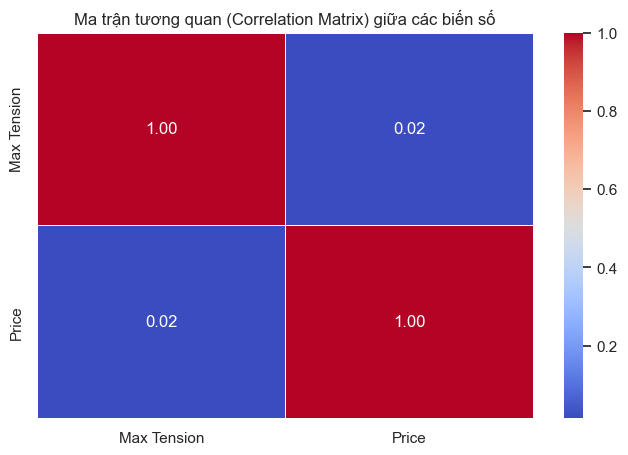

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix) giữa các biến số')
plt.show()

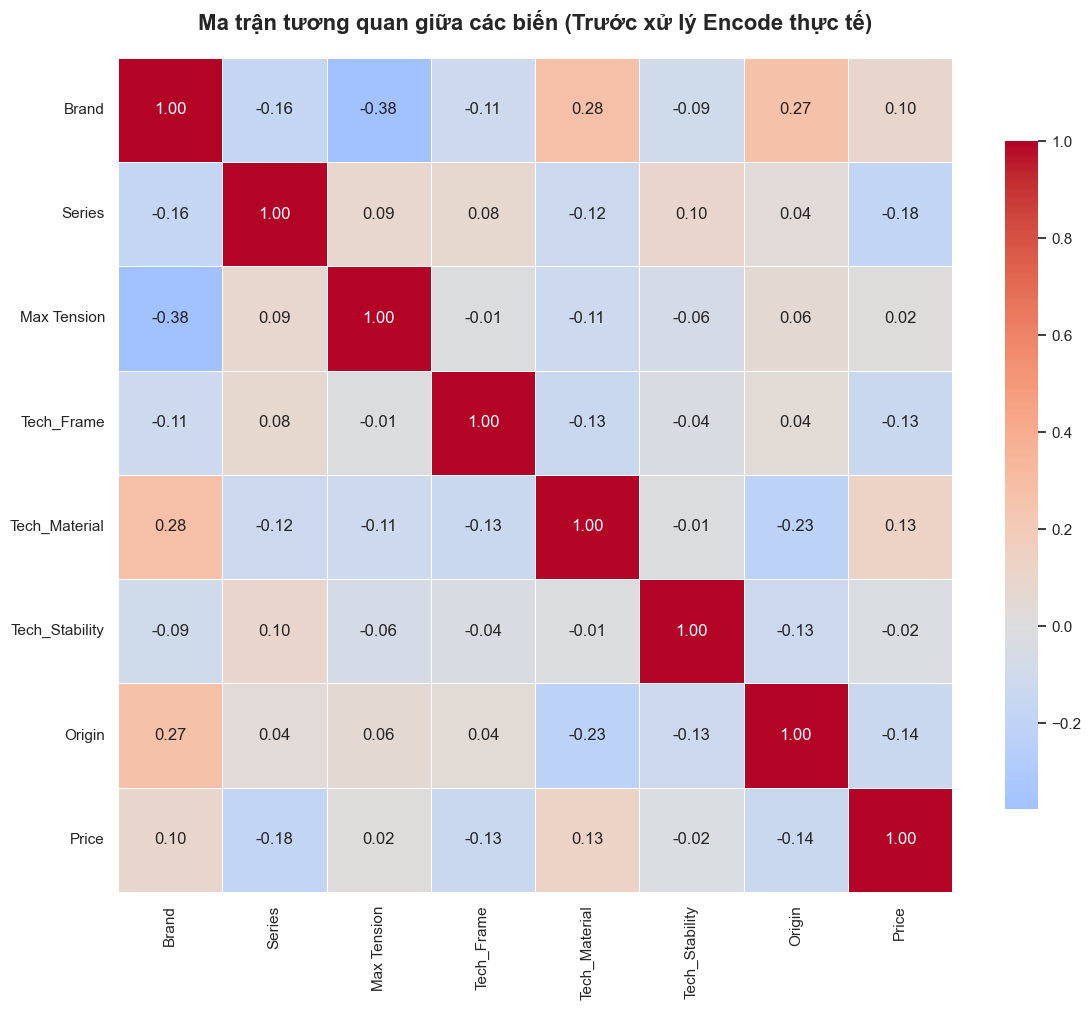


Mức độ tương quan (Correlation) của các đặc trưng với 'Price':
 - Tech_Material  :  0.1280
 - Brand          :  0.0970
 - Max Tension    :  0.0154
 - Tech_Stability : -0.0235
 - Tech_Frame     : -0.1337
 - Origin         : -0.1353
 - Series         : -0.1779


In [8]:
# biểu đồ tương quan
from sklearn.preprocessing import LabelEncoder
df_corr = df.copy()
le = LabelEncoder()
columns_to_encode = ['Brand', 'Series', 'Origin', 'Tech_Frame', 'Tech_Material', 'Tech_Stability']
for col in columns_to_encode:
    if col in df_corr.columns:
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))
correlation_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến (Trước xử lý Encode thực tế)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("\nMức độ tương quan (Correlation) của các đặc trưng với 'Price':")
price_corr = correlation_matrix['Price'].sort_values(ascending=False)
for feature, corr_value in price_corr.items():
    if feature != 'Price':
        print(f" - {feature:15s}: {corr_value:>7.4f}")



In [9]:
print(f"Data trước xử lý: {df.shape}")

df['Tech_Frame'] = df['Tech_Frame'].fillna('None')
df['Tech_Material'] = df['Tech_Material'].fillna('None')
df['Tech_Stability'] = df['Tech_Stability'].fillna('None')

df = df.dropna().reset_index(drop=True)



def one_hot_encode(df_target, column):
    unique_vals = sorted(df_target[column].dropna().unique())
    one_hot_df = pd.DataFrame(
        {f"{column}_{val}": (df_target[column] == val).astype(int) for val in unique_vals},
        index=df_target.index
    )
    return pd.concat([df_target.drop(columns=[column]), one_hot_df], axis=1)

df = one_hot_encode(df, column='Brand')
df = one_hot_encode(df, column='Origin')

def multi_hot_encode(df_target, column):
    all_tags = set()
    for item in df_target[column].dropna():
        tags = [tag.strip() for tag in str(item).split(',')]
        all_tags.update(tags)
        
    if 'None' in all_tags:
        all_tags.remove('None')
    all_tags = sorted(list(all_tags))
    
    multi_hot_dict = {}
    for tag in all_tags:
        col_name = f"{column}_{tag}"
        multi_hot_dict[col_name] = df_target[column].astype(str).apply(
            lambda x: 1 if tag in [t.strip() for t in x.split(',')] else 0
        )
        
    multi_hot_df = pd.DataFrame(multi_hot_dict, index=df_target.index)
    return pd.concat([df_target.drop(columns=[column]), multi_hot_df], axis=1)

# Multi-Hot cho các cột Tech
df = multi_hot_encode(df, column='Tech_Frame')
df = multi_hot_encode(df, column='Tech_Material')
df = multi_hot_encode(df, column='Tech_Stability')

print(" Kích thước dataset sau Multi/One Hot Encoding:", df.shape)



Data trước xử lý: (6256, 8)
 Kích thước dataset sau Multi/One Hot Encoding: (6236, 251)


## Train-Test Split + Target Encoding 'Series'

In [10]:
from sklearn.model_selection import train_test_split
# 1. Tách các cột Features (X) và Target (y)
X = df.drop('Price', axis=1)
y = df['Price']
# 2. CHIA TẬP TRAIN-TEST NGAY TỪ ĐẦU để chặn Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
# 3. Tính toán Target Encoding (Price Mean của Series) CHỈ TRÊN TẬP TRAIN
train_temp = X_train.copy()
train_temp['Price'] = y_train
series_price_mean = train_temp.groupby('Series')['Price'].mean()
# Lưu lại mức giá trung bình của toàn bộ tập Train đề phòng tập Test có Series mới
global_mean = y_train.mean()
# 4. Áp dụng lại (map) cấu trúc Encoding lên tập Train và tập Test
X_train['Series_Encoded'] = X_train['Series'].map(series_price_mean).fillna(global_mean)
X_test['Series_Encoded'] = X_test['Series'].map(series_price_mean).fillna(global_mean)
# Nhớ Xóa cột Series dạng String nguyên quy bản đầu
X_train = X_train.drop('Series', axis=1)
X_test = X_test.drop('Series', axis=1)
print("\n✓ Target Encoding applied correctly without Data Leakage!")

Training set: 4988 samples
Testing set: 1248 samples

✓ Target Encoding applied correctly without Data Leakage!


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import optuna

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth    = trial.suggest_int('max_depth', 5, 30)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0])
    
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                   max_features=max_features, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Optuna tự biết nên thử gì tiếp theo

print("Best params:", study.best_params)


d:\dut_ai\AIO_code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-07 00:14:24,120] A new study created in memory with name: no-name-eab2e4d8-d6c0-42a1-a308-f2e6cd771b45
[I 2026-03-07 00:14:46,652] Trial 0 finished with value: 0.9299079345122354 and parameters: {'n_estimators': 338, 'max_depth': 30, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9299079345122354.
[I 2026-03-07 00:15:19,357] Trial 1 finished with value: 0.677448724194106 and parameters: {'n_estimators': 457, 'max_depth': 5, 'max_features': 1.0}. Best is trial 0 with value: 0.9299079345122354.
[I 2026-03-07 00:16:13,698] Trial 2 finished with value: 0.9236597032698292 and parameters: {'n_estimators': 396, 'max_depth': 17, 'max_features': 1.0}. Best is trial 0 with value: 0.9299079345122354.
[I 2026-03-07 00:16:29,133] Trial 3

Best params: {'n_estimators': 416, 'max_depth': 28, 'max_features': 1.0}


## Random Forest Model Training



In [14]:
from sklearn.ensemble import RandomForestRegressor
import time

# Lấy best_params từ Optuna và ép kiểu an toàn
safe_params = {
    'n_estimators': int(study.best_params['n_estimators']),
    'max_depth':    int(study.best_params['max_depth']),
    'max_features': study.best_params['max_features'],
}

model = RandomForestRegressor(
    **safe_params,
    random_state=42,
    n_jobs=-1
)

print("Best params from Optuna:", safe_params)
print("\n" + "="*60)
print("TRAINING MODEL...")
print("="*60)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"\n✓ Training completed!")
print(f"Training time: {training_time:.4f} seconds")


Best params from Optuna: {'n_estimators': 416, 'max_depth': 28, 'max_features': 1.0}

TRAINING MODEL...

✓ Training completed!
Training time: 2.8202 seconds


## Model Evaluation



In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán và đo thời gian
start_time = time.time()
y_train_pred = model.predict(X_train)
train_pred_time = time.time() - start_time

start_time = time.time()
y_test_pred = model.predict(X_test)
test_pred_time = time.time() - start_time

# Tính toán metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Hiển thị kết quả
print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print("\n📊 TRAINING SET:")
print(f"  MAE:  {train_mae:,.0f} VND")
print(f"  MSE:  {train_mse:,.0f}")
print(f"  RMSE: {train_rmse:,.0f} VND")
print(f"  R² Score: {train_r2:.4f}")
print(f"  Prediction time: {train_pred_time:.4f} seconds")

print("\n📊 TESTING SET:")
print(f"  MAE:  {test_mae:,.0f} VND")
print(f"  MSE:  {test_mse:,.0f}")
print(f"  RMSE: {test_rmse:,.0f} VND")
print(f"  R² Score: {test_r2:.4f}")
print(f"  Prediction time: {test_pred_time:.4f} seconds")

print("\n📈 OVERALL PERFORMANCE:")
print(f"  Accuracy (R²): {test_r2*100:.2f}%")
print(f"  Average error: ±{test_mae:,.0f} VND")
print(f"  Total time: Training={training_time:.2f}s + Prediction={test_pred_time:.4f}s")

MODEL EVALUATION RESULTS

📊 TRAINING SET:
  MAE:  85,149 VND
  MSE:  57,088,445,476
  RMSE: 238,932 VND
  R² Score: 0.9675
  Prediction time: 0.1513 seconds

📊 TESTING SET:
  MAE:  134,995 VND
  MSE:  148,403,441,310
  RMSE: 385,232 VND
  R² Score: 0.9230
  Prediction time: 0.1034 seconds

📈 OVERALL PERFORMANCE:
  Accuracy (R²): 92.30%
  Average error: ±134,995 VND
  Total time: Training=2.82s + Prediction=0.1034s


## Performance Visualization



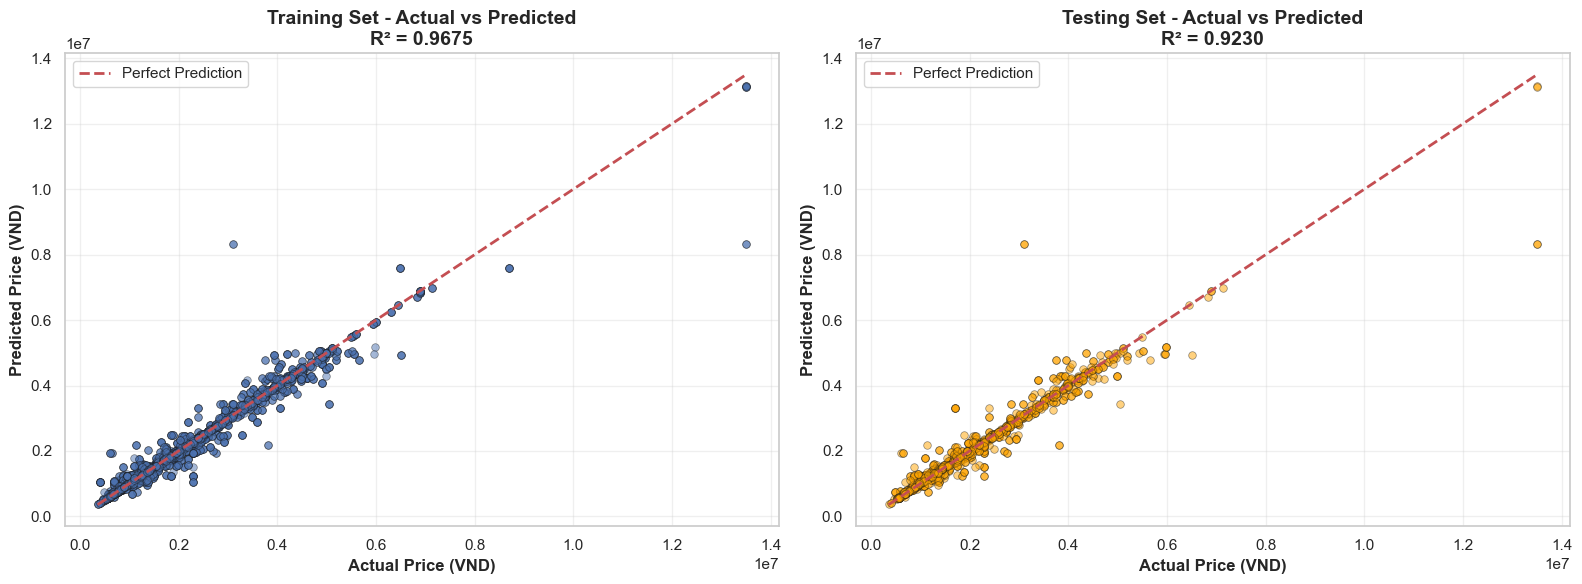

In [16]:
import matplotlib.pyplot as plt

# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (VND)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Price (VND)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Training Set - Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (VND)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Price (VND)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Testing Set - Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calculating learning curve...
n_estimators=10 - Train R2: 0.9545, Test R2: 0.8920
n_estimators=60 - Train R2: 0.9558, Test R2: 0.8950
n_estimators=110 - Train R2: 0.9554, Test R2: 0.8960
n_estimators=160 - Train R2: 0.9552, Test R2: 0.8959
n_estimators=210 - Train R2: 0.9552, Test R2: 0.8957
n_estimators=260 - Train R2: 0.9552, Test R2: 0.8959
n_estimators=310 - Train R2: 0.9552, Test R2: 0.8962
n_estimators=360 - Train R2: 0.9551, Test R2: 0.8960
n_estimators=410 - Train R2: 0.9552, Test R2: 0.8961
n_estimators=460 - Train R2: 0.9551, Test R2: 0.8961


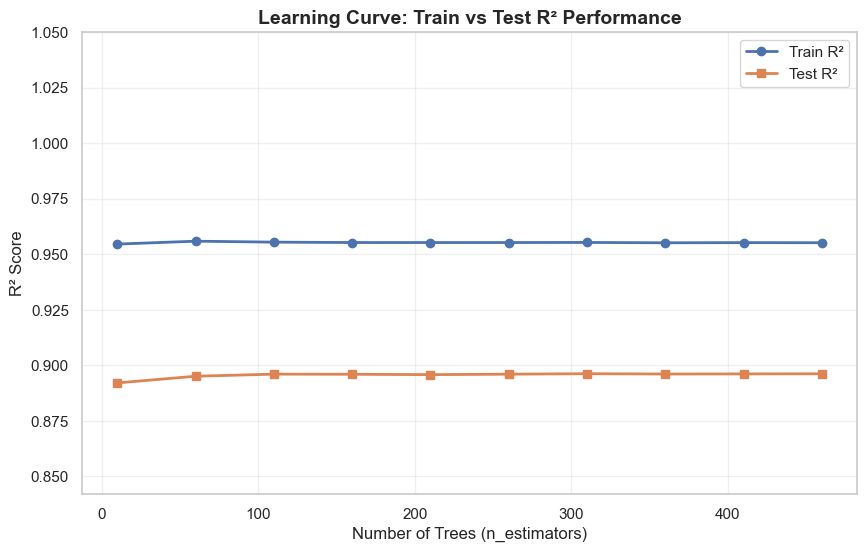

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Khởi tạo danh sách lưu kết quả
n_trees_range = range(10, 501, 50)
train_scores = []
test_scores = []

print("Calculating learning curve...")
for n in n_trees_range:
    # Huấn luyện mô hình tạm thời với n cây
    # Sử dụng RandomForestRegressor từ sklearn (đã import ở cell trên)
    temp_rf = RandomForestRegressor(n_estimators=n, max_depth=20, min_samples_split=2, min_samples_leaf=2, max_features=1.0, random_state=42, n_jobs=-1)
    temp_rf.fit(X_train, y_train)
    
    # Tính toán R2
    train_score = r2_score(y_train, temp_rf.predict(X_train))
    test_score = r2_score(y_test, temp_rf.predict(X_test))
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    print(f"n_estimators={n} - Train R2: {train_score:.4f}, Test R2: {test_score:.4f}")

# 2. Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(n_trees_range, train_scores, label='Train R²', marker='o', linewidth=2)
plt.plot(n_trees_range, test_scores, label='Test R²', marker='s', linewidth=2)

plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curve: Train vs Test R² Performance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(min(test_scores) - 0.05, 1.05) 
plt.show()

## Feature Importance Visualization



C:\Users\khacb\AppData\Local\Temp\ipykernel_23920\1329603742.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


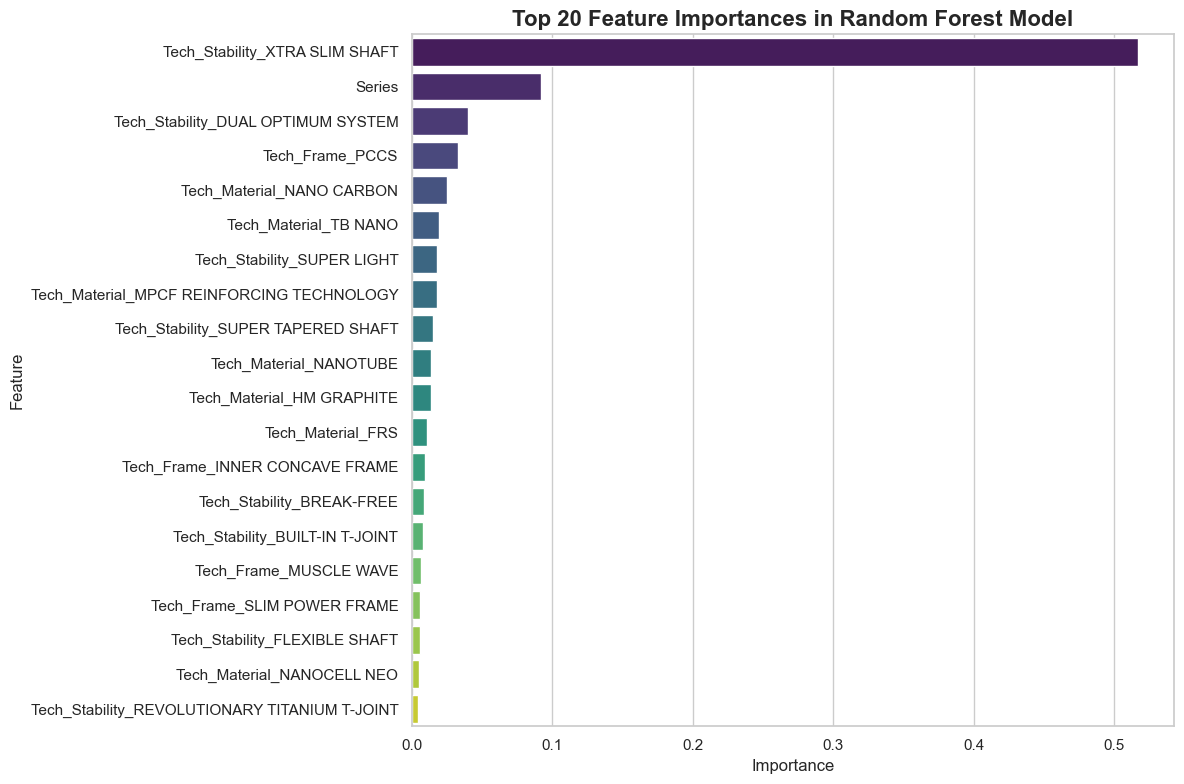

In [18]:
import pandas as pd
import seaborn as sns

# Lấy feature importances từ mô hình
importances = model.feature_importances_
feature_names = X.columns

# Tạo DataFrame để dễ vẽ đồ thị
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sắp xếp theo độ quan trọng giảm dần và lấy top 20
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Feature Importances in Random Forest Model', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
class DecisionNode:
    def __init__(self,feature=None, threshold = None, left = None, right=None,value = None):
        self.feature = feature
        self.threshold = threshold  #nguong split
        self.left = left    #node trai (<= threshold)
        self.right = right #node phai (> threshold)
        self.value = value  #gia tri du doan (leaf)

class DecisionTree:
    def __init__ (self, max_depth = 10, min_samples_split=5, n_features = None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features #so luong feature ngau nhien moi split
        self.root = None
    def mse(self,y):
        return np.mean((y-np.mean(y))**2) if len(y) >0 else 0
    def best_split(self, X, y):
        best_gain = -np.inf
        best_feat, best_thresh = None, None
        n_samples, n_cols = X.shape
        # Chọn ngẫu nhiên n_features cột (dùng cho RF)
        feat_ids = np.random.choice(n_cols, self.n_features or n_cols, replace=False)
        parent_mse = self.mse(y)
        for feat in feat_ids:
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                left_mask  = X[:, feat] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                # Information gain = giảm MSE sau split
                gain = parent_mse - (
                    left_mask.sum()  / n_samples * self.mse(y[left_mask]) +
                    right_mask.sum() / n_samples * self.mse(y[right_mask])
                )
                if gain > best_gain:
                    best_gain   = gain
                    best_feat   = feat
                    best_thresh = thresh
        return best_feat, best_thresh
    def build(self, X, y, depth=0):
        # Điều kiện dừng → tạo leaf node
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return DecisionNode(value=np.mean(y))
        feat, thresh = self.best_split(X, y)
        if feat is None:                          # không tìm được split
            return DecisionNode(value=np.mean(y))
        left_mask = X[:, feat] <= thresh
        left  = self.build(X[left_mask],  y[left_mask],  depth + 1)
        right = self.build(X[~left_mask], y[~left_mask], depth + 1)
        return DecisionNode(feature=feat, threshold=thresh, left=left, right=right)
    def fit(self, X, y):
        self.root = self.build(X, y)
    # ── Predict 1 mẫu ──
    def predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_one(x, node.left)
        return self.predict_one(x, node.right)
    def predict(self, X):
        return np.array([self.predict_one(x, self.root) for x in X])

In [20]:
class RandomForestRegressor:
    def __init__(self, n_estimators=100, max_depth=10, min_samples_split=5, n_features='sqrt'):
        self.n_estimators     = n_estimators
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.n_features_mode  = n_features
        self.trees            = []
    def fit(self, X, y):
        self.trees = []
        n_samples, n_cols = X.shape
        # Số feature mỗi split
        if self.n_features_mode == 'sqrt':
            n_feat = int(np.sqrt(n_cols))
        elif self.n_features_mode == 'log2':
            n_feat = int(np.log2(n_cols))
        else:
            n_feat = n_cols
        for i in range(self.n_estimators):
            # Bootstrap sampling
            boot_idx = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X[boot_idx], y[boot_idx]
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=n_feat
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
            if (i + 1) % 10 == 0:
                print(f"  Tree {i+1}/{self.n_estimators} done")
    def predict(self, X):
        # Trung bình prediction của tất cả cây
        preds = np.array([tree.predict(X) for tree in self.trees])
        return preds.mean(axis=0)